In [19]:
import numpy as np
import scipy.stats
import scipy.special
import scipy.optimize
import scipy.integrate

#x y yerr
data = np.loadtxt(
    '/home/marli/Bayesian_Stats/Bayesian-Stats-HS2026/lectures/data/linear_fits/data_1.txt'       
)

x=data[:,0]
y= data[:,1]
yerr = data[:,2]


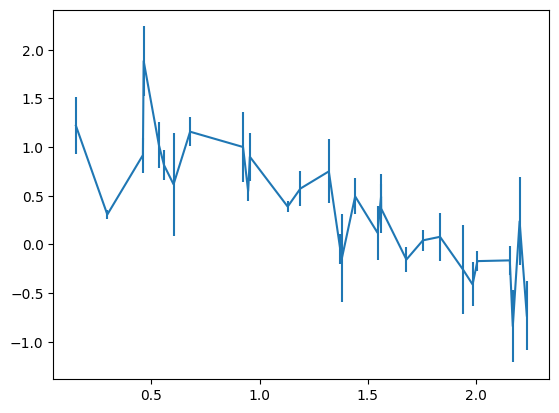

In [16]:
import matplotlib.pyplot as plt

plt.errorbar(x, y, yerr=yerr)
#plt.legend()
plt.show()

In [17]:
# The linear model
def model(m, b, x):
    return m*x + b

# Probability of the data, given the model parameters: P(y|m, b)
# We use the logarithm here for computational reasons
def log_likelihood_probability(y, m, b, x, sigma_y):
    prediction = model(m, b, x)

    n = len(y)
    # log of the PDF of a multivariate Gaussian
    return (
        -0.5 * np.sum((y - prediction)**2/sigma_y**2)  # Exponent
        - n/2*np.log(2*np.pi*sigma_y**2)               # Normalisation
    )

In [31]:
m_prior = scipy.stats.norm(loc=-1, scale=1)
b_prior = scipy.stats.norm(loc=1, scale=1.2)

def log_prior_probability(m, b):
    return m_prior.logpdf(m) + b_prior.logpdf(b)

In [32]:
def sample_prior(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((m_prior.rvs(n_sample), b_prior.rvs(n_sample))).T

# Fix the pseudo random number generator seed for reproducibility
np.random.seed(42)

# Evaluate the model at the prior sample parameters
prior_model_predictive = np.array(
    [model(*parameters, x) for parameters in sample_prior(n_sample=20)]
)

In [33]:
def plot_linear_data_set(x, y, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)

    if y_err is not None:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    else:
        ax.plot(x, y, marker=".", linestyle="none", label="Data")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left")

    return fig, ax

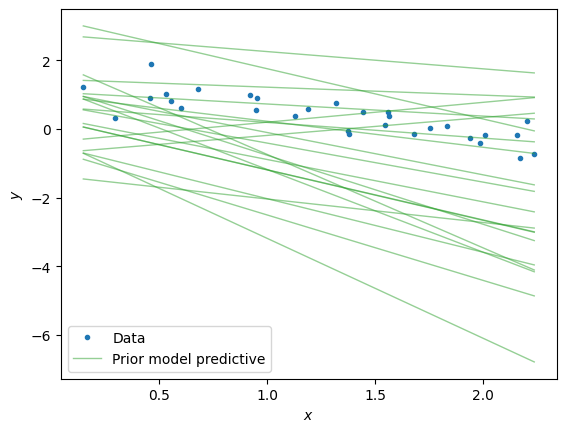

In [34]:
_, ax = plot_linear_data_set(x, y)

style = dict(c="C2", lw=1, alpha=0.5)
ax.plot(x, prior_model_predictive.T, **style)
ax.plot([], [], label="Prior model predictive", **style)
ax.legend();

In [41]:
# Since we have a Gaussian likelihood, we can add Gaussian noise with the 
# correct variance to our prior model predictions
sigma_y = yerr[0]

prior_predictive = (
    prior_model_predictive
    + yerr*np.random.normal(size=prior_model_predictive.shape)
)

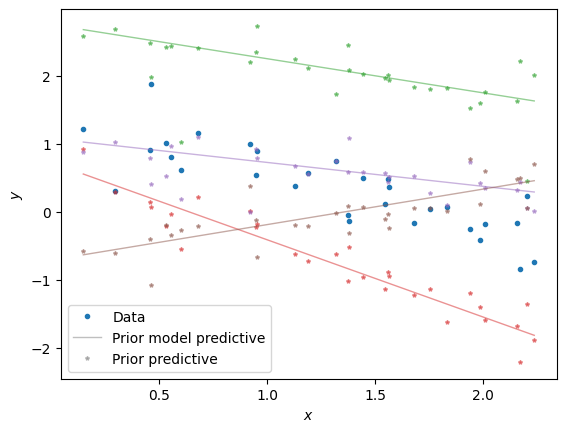

In [42]:
_, ax = plot_linear_data_set(x, y)

pmp_style = dict(lw=1, alpha=0.5)
pp_style = dict(ls="none", marker="*", ms=3, alpha=0.5)

for i in range(4):
    ax.plot(x, prior_model_predictive[i], c=f"C{i+2}", **pmp_style)
    ax.plot(x, prior_predictive[i], c=f"C{i+2}", **pp_style)

ax.plot([], [], label="Prior model predictive", c="grey", **pmp_style)
ax.plot([], [], label="Prior predictive", c="grey", **pp_style)
ax.legend();

In [43]:
def log_posterior_probability(m, b, x, sigma_y, y):
    return (
        log_likelihood_probability(y, m, b, x, sigma_y)
        + log_prior_probability(m, b)
    )

In [44]:
# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior(theta, x, sigma_y, y):
    m, b = theta
    return -log_posterior_probability(m, b, x, sigma_y, y)

MAP_result = scipy.optimize.minimize(
    fun=negative_log_posterior,
    x0=(1, 0),
    args=(x, sigma_y, y)
)
m_MAP, b_MAP = MAP_result.x
m_true = -0.7
b_true = 1.2

print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")
print(f"m_true = {m_true:.3f}, b_true = {b_true:.3f}")

MAP results
m_MAP = -0.792, b_MAP = 1.397
m_true = -0.700, b_true = 1.200


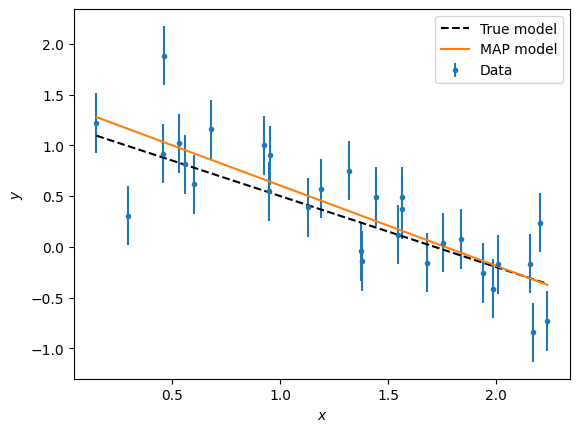

In [45]:
_, ax = plot_linear_data_set(x, y, sigma_y)

x_grid = np.linspace(0, 2.5, 100)
ax.plot(x, model(m_true, b_true, x), c="k", ls="--", label="True model")
ax.plot(x, model(m_MAP, b_MAP, x), c="C1", label="MAP model")
ax.legend();